In [5]:
%run setup.py

import pandas as pd
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

2025-11-25 19:44:24.851645: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-25 19:44:26.825174: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-25 19:44:29.881039: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764110671.777901   10119 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764110672.106787   10119 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764110675.293703   10119 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
def preprocessing(df, sensor_columns):
    x_list = []

    for col in sensor_columns:
        sensor_data = np.stack(df[col].values)
        x_list.append(sensor_data)
    
    X = np.stack(x_list, axis=2)

    le = LabelEncoder()
    y = le.fit_transform(df['label'])

    return X, y, le

In [10]:
def cnn_1d_model(input_shape, num_classes):
    model = models.Sequential()

    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv1D(filters=64, kernel_size=50, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.AveragePooling1D(pool_size=2))
    model.add(layers.Dropout(0.1))

    model.add(layers.Conv1D(filters=64, kernel_size=25, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.AveragePooling1D(pool_size=2))
    model.add(layers.Dropout(0.1))

    model.add(layers.GlobalAveragePooling1D())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [11]:
def cnn_1d_model_2_way(input_shape, num_classes):
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv1D(filters=64, kernel_size=20, activation='relu', padding='same')(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(filters=128, kernel_size=10, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    dynamic_features = layers.GlobalAveragePooling1D()(x)

    static_features = layers.GlobalAveragePooling1D()(input_layer)

    combined = layers.Concatenate()([dynamic_features, static_features])

    z = layers.Dense(64, activation='relu')(combined)
    z = layers.Dropout(0.2)(z)
    output_layer = layers.Dense(num_classes, activation='softmax')(z)

    model = models.Model(inputs=input_layer, outputs=output_layer)

    model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    
    return model

In [3]:
def show_metrics(accuracies, f1_scores, matrices, classes):
    print("Accuracy:", np.mean(accuracies))
    print("F1 Score (weighted):", np.mean([f[0] for f in f1_scores]))
    print("F1 Score (macro):", np.mean([f[1] for f in f1_scores]))

    global_matrix = np.sum(matrices, axis=0)

    disp = ConfusionMatrixDisplay(confusion_matrix=global_matrix, display_labels=classes)
    disp.plot(xticks_rotation=45)
    plt.show()

In [6]:
df = pl.read_parquet("../data/DogDeepLearning.parquet")
df = df.to_pandas()

In [7]:
unique_classes, count = np.unique(df["label"], return_counts=True)
total_sample = len(df)
n_classes = len(unique_classes)

weights = {}
for cls, cnt in zip(unique_classes, count):
    weight = total_sample / (n_classes * cnt)
    weights[cls] = weight

Training and evaluating for DogID: 73 (1/10)
Training and evaluating for DogID: 34 (2/10)
Training and evaluating for DogID: 45 (3/10)
Training and evaluating for DogID: 44 (4/10)
Training and evaluating for DogID: 55 (5/10)
Training and evaluating for DogID: 27 (6/10)
Training and evaluating for DogID: 16 (7/10)
Training and evaluating for DogID: 63 (8/10)
Training and evaluating for DogID: 29 (9/10)
Training and evaluating for DogID: 48 (10/10)
Accuracy: 0.8673105776309967
F1 Score (weighted): 0.8622419648493926
F1 Score (macro): 0.8621505992783085


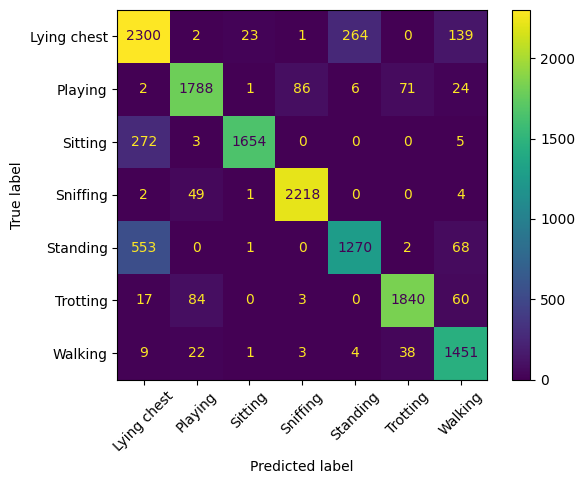

In [11]:
sensor_cols = [
    'ABack_x', 'ABack_y', 'ABack_z',
    'ANeck_x', 'ANeck_y', 'ANeck_z',
    'GBack_x', 'GBack_y', 'GBack_z',
    'GNeck_x', 'GNeck_y', 'GNeck_z'
]

dogs_tests = [73, 34, 45, 44, 55, 27, 16, 63, 29, 48]

accuracies = []
f1_scores = []
matrices = []

for i, dog_id in enumerate(dogs_tests):
    print(f"Training and evaluating for DogID: {dog_id} ({i+1}/{len(dogs_tests)})")
    df_train = df[df["DogID"] != dog_id].copy()
    df_test = df[df["DogID"] == dog_id].copy()

    X_train, y_train, le = preprocessing(df_train, sensor_cols)
    X_test, y_test, _ = preprocessing(df_test, sensor_cols)

    num_classes = len(np.unique(y_train))

    model = cnn_1d_model(input_shape=(200, 12), num_classes=num_classes)

    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        class_weight=weights,
        epochs=15,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[callback],
        verbose=0
    )

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')

    cm = confusion_matrix(y_test, y_pred)
    matrices.append(cm)

    accuracies.append(model.evaluate(X_test, y_test, verbose=0)[1])
    f1_scores.append((f1_weighted, f1_macro))

show_metrics(accuracies, f1_scores, matrices, le.classes_)
